IMPORTS

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


In [25]:
# Converting to dataframes
gold_belga_press_articles_df = pd.read_csv('../data/raw/gold_belga_press_articles.csv', sep=',', on_bad_lines='skip')
gold_google_trends_daily_df = pd.read_csv('../data/raw/gold_google_trends_daily.csv', sep=',', on_bad_lines='skip')
gold_match_context_df = pd.read_csv('../data/raw/gold_match_context.csv', sep=',', on_bad_lines='skip')
gold_match_df = pd.read_csv('../data/raw/gold_match.csv', sep=',', on_bad_lines='skip')

# Filter to home games only and bring in tickets_scanned (target variable)
home_matches = gold_match_df[gold_match_df['is_home_match'] == True][['match_id', 'tickets_scanned']]
gold_match_context_df = gold_match_context_df.merge(home_matches, on='match_id', how='inner')

print(f"Home games: {len(gold_match_context_df)}")
gold_match_context_df.head(5)

Home games: 71


,match_id,match_date,weather_temp_max_c,weather_temp_min_c,weather_temp_mean_c,weather_precipitation_mm,weather_rain_mm,weather_snowfall_cm,weather_windspeed_max_kmh,weather_sunshine_hours,...,is_midweek,academic_year,academic_week,is_public_holiday,public_holiday_name,is_school_holiday_flanders,school_holiday_name,pct_free_tickets,campaign_motto,tickets_scanned
0,d256yo3eng04m0fu7b4sl7wno,2022-07-30,25.8,12.9,19.8,0.0,0.0,0.0,10.2,10.3,...,False,2021/2022,48,False,NaN,True,Summer Holiday,13.9,NaN,5565.0
1,d4mn5ksbxuvnaww4pmommxhqs,2022-08-14,32.2,17.3,25.4,0.0,0.0,0.0,16.9,11.1,...,False,2021/2022,50,False,NaN,True,Summer Holiday,8.3,NaN,7440.0
2,d65hmi7sq03yzr5he1k7ypus4,2022-08-27,21.0,15.9,18.7,0.0,0.0,0.0,13.7,3.9,...,False,2021/2022,52,False,NaN,True,Summer Holiday,14.8,NaN,4489.0
3,d80mkemezkz16bqh6lbn8tlhw,2022-09-10,18.9,13.6,15.7,8.6,8.6,0.0,23.5,4.1,...,False,2022/2023,2,False,NaN,False,NaN,68.7,NaN,4508.0
4,dak40etbhbqsr1nxyt50qcg0k,2022-10-01,17.8,10.9,14.2,9.8,9.8,0.0,34.5,8.5,...,False,2022/2023,5,False,NaN,False,NaN,7.5,NaN,6290.0


In [26]:
# Extracting features

# Match Google Trends interest to match dates
match_trends = gold_google_trends_daily_df[
    gold_google_trends_daily_df['match_id'].notna()
][['match_id', 'ohl_interest']].drop_duplicates()

# Merge ohl_interest into match context
gold_match_context_df = gold_match_context_df.merge(
    match_trends,
    on='match_id',
    how='left'
)

# Convert dates to datetime
gold_match_context_df['match_date'] = pd.to_datetime(
    gold_match_context_df['match_date']
)

# Count OHL-linked articles in 7 days before each match using the pre-linked match_id
articles_per_match = (
    gold_belga_press_articles_df[
        gold_belga_press_articles_df['match_id'].notna() &
        (gold_belga_press_articles_df['days_to_match'] >= -7) &
        (gold_belga_press_articles_df['days_to_match'] <= 0)
    ]
    .groupby('match_id')
    .size()
    .reset_index(name='press_articles_7d')
)

gold_match_context_df = gold_match_context_df.merge(
    articles_per_match,
    on='match_id',
    how='left'
)
gold_match_context_df['press_articles_7d'] = gold_match_context_df['press_articles_7d'].fillna(0)

# Combine all features
analysis_df = gold_match_context_df[[
    'match_id',
    'match_date',
    'weather_score',
    'weather_rain_mm',
    'weather_temp_mean_c',
    'weather_temp_deviation',
    'weather_windspeed_max_kmh',
    'weather_sunshine_hours',
    'ohl_interest',
    'press_articles_7d',
    'tickets_scanned'
]].copy()

# Handle any missing values
analysis_df = analysis_df.dropna()

print(analysis_df.head())
print(f"\nTotal home matches for analysis: {len(analysis_df)}")
print(f"\npress_articles_7d distribution:")
print(analysis_df['press_articles_7d'].describe())

                    match_id match_date  weather_score  weather_rain_mm  \
0  d256yo3eng04m0fu7b4sl7wno 2022-07-30           0.09              0.0   
1  d4mn5ksbxuvnaww4pmommxhqs 2022-08-14           0.59              0.0   
2  d65hmi7sq03yzr5he1k7ypus4 2022-08-27          -0.08              0.0   
3  d80mkemezkz16bqh6lbn8tlhw 2022-09-10          -3.64              8.6   
4  dak40etbhbqsr1nxyt50qcg0k 2022-10-01          -3.83              9.8   

   weather_temp_mean_c  weather_temp_deviation  weather_windspeed_max_kmh  \
0                 19.8                     0.9                       10.2   
1                 25.4                     5.9                       16.9   
2                 18.7                    -0.8                       13.7   
3                 15.7                    -0.6                       23.5   
4                 14.2                     1.1                       34.5   

   weather_sunshine_hours  ohl_interest  press_articles_7d  tickets_scanned  
0       

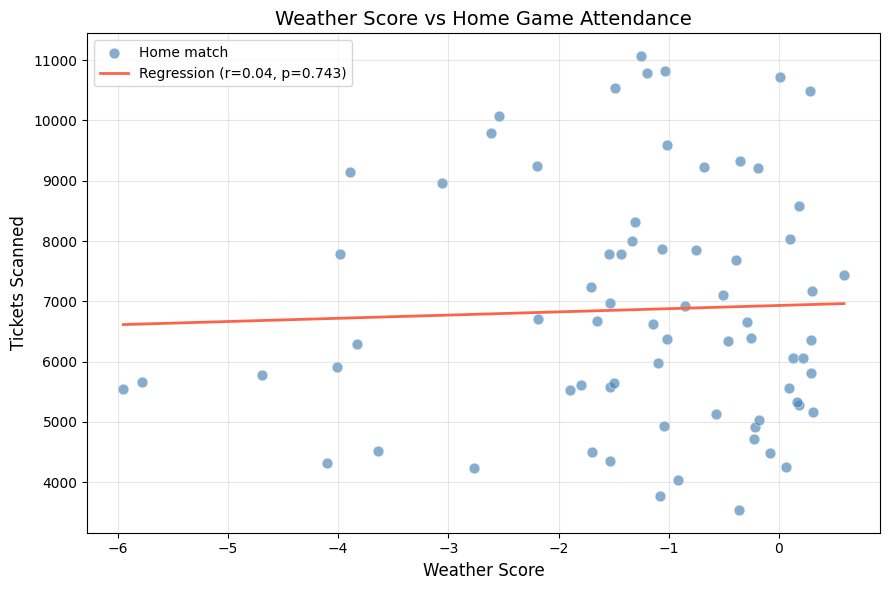

r = 0.040  |  r² = 0.002  |  p = 0.743


In [27]:
x = analysis_df['weather_score']
y = analysis_df['tickets_scanned']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(9, 6))
plt.scatter(x, y, alpha=0.65, edgecolors='white', linewidth=0.5, s=60, color='steelblue', label='Home match')
plt.plot(x_line, y_line, color='tomato', linewidth=2,
         label=f'Regression (r={r_value:.2f}, p={p_value:.3f})')
plt.xlabel('Weather Score', fontsize=12)
plt.ylabel('Tickets Scanned', fontsize=12)
plt.title('Weather Score vs Home Game Attendance', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"r = {r_value:.3f}  |  r² = {r_value**2:.3f}  |  p = {p_value:.3f}")


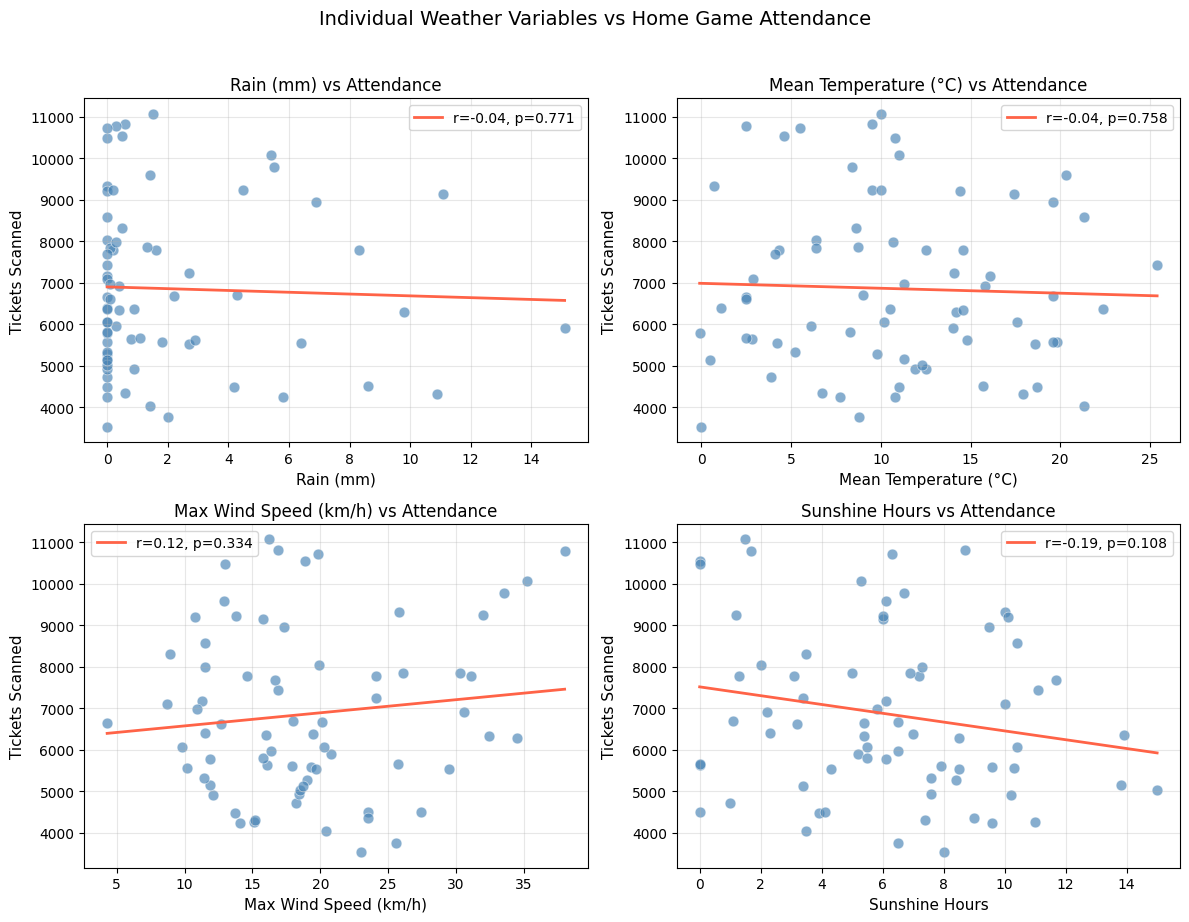

In [28]:
weather_vars = {
    'weather_rain_mm': 'Rain (mm)',
    'weather_temp_mean_c': 'Mean Temperature (°C)',
    'weather_windspeed_max_kmh': 'Max Wind Speed (km/h)',
    'weather_sunshine_hours': 'Sunshine Hours',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(weather_vars.items()):
    x = analysis_df[col]
    y = analysis_df['tickets_scanned']

    slope, intercept, r_value, p_value, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)

    plt.sca(axes[i])
    plt.scatter(x, y, alpha=0.65, edgecolors='white', linewidth=0.5, s=60, color='steelblue')
    plt.plot(x_line, slope * x_line + intercept, color='tomato', linewidth=2,
             label=f'r={r_value:.2f}, p={p_value:.3f}')
    plt.xlabel(label, fontsize=11)
    plt.ylabel('Tickets Scanned', fontsize=11)
    plt.title(f'{label} vs Attendance', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

plt.suptitle('Individual Weather Variables vs Home Game Attendance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Rainfall (mm):
The relationship between rainfall and attendance appears to be negligible. The correlation is extremely weak and slightly negative (r = -0.04), indicating that increased rainfall does not meaningfully reduce attendance. Additionally, the high p-value suggests that this relationship is not statistically significant. Overall, this implies that light to moderate rain does not deter fans from attending matches, and rainfall alone is not a reliable predictor of attendance.

Mean Temperature (°C):
Mean temperature shows virtually no relationship with attendance (r = -0.04), with data points widely dispersed across all temperature ranges. This suggests that attendance remains relatively stable regardless of whether conditions are colder or warmer within the observed range. The lack of statistical significance further confirms that temperature does not play a decisive role in influencing match attendance.

Maximum Wind Speed (km/h):
Wind speed exhibits a weak positive correlation with attendance (r = 0.12), but this relationship is not statistically significant. The slight upward trend is likely due to random variation rather than a meaningful effect. In practice, wind conditions do not appear to influence fans’ decisions to attend matches, and this variable is unlikely to contribute strongly to predictive performance.

Sunshine Hours:
Sunshine hours show a weak negative relationship with attendance (r = -0.19), suggesting that higher sunshine levels may be associated with slightly lower attendance. However, this relationship is not statistically significant. One possible interpretation is that better weather encourages alternative leisure activities, reducing stadium turnout, but the evidence is not strong enough to confirm this. As such, sunshine should be considered a minor and uncertain factor.

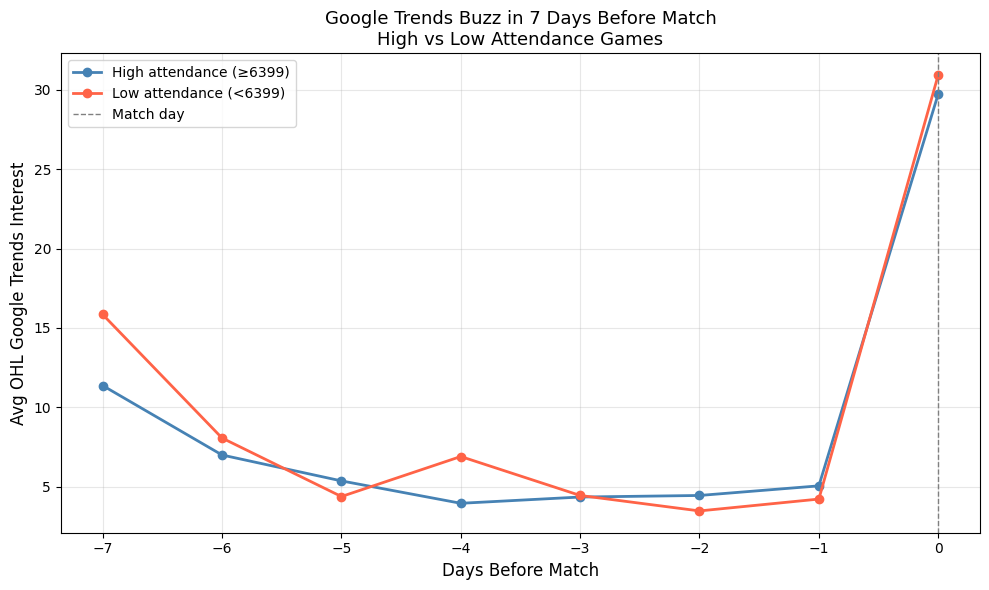

Median attendance split: 6399 tickets


In [29]:
trends_df = gold_google_trends_daily_df.copy()
trends_df['date'] = pd.to_datetime(trends_df['date'])

# For each home match, extract ohl_interest for days -7 to 0
records = []
for _, match in analysis_df.iterrows():
    match_date = match['match_date']
    window = trends_df[
        (trends_df['date'] >= match_date - pd.Timedelta(days=7)) &
        (trends_df['date'] <= match_date)
    ].copy()
    window['days_before'] = (window['date'] - match_date).dt.days  # 0 = match day
    window['match_id'] = match['match_id']
    window['tickets_scanned'] = match['tickets_scanned']
    records.append(window)

pre_match_trends = pd.concat(records, ignore_index=True)

# Split matches into high / low attendance by median
median_att = analysis_df['tickets_scanned'].median()
pre_match_trends['attendance_group'] = np.where(
    pre_match_trends['tickets_scanned'] >= median_att, 'High attendance', 'Low attendance'
)

# Average interest per day-before-match for each group
grouped = pre_match_trends.groupby(['attendance_group', 'days_before'])['ohl_interest'].mean().reset_index()

high = grouped[grouped['attendance_group'] == 'High attendance']
low  = grouped[grouped['attendance_group'] == 'Low attendance']

plt.figure(figsize=(10, 6))
plt.plot(high['days_before'], high['ohl_interest'], marker='o', color='steelblue',  linewidth=2, label=f'High attendance (≥{median_att:.0f})')
plt.plot(low['days_before'],  low['ohl_interest'],  marker='o', color='tomato',     linewidth=2, label=f'Low attendance (<{median_att:.0f})')
plt.axvline(0, color='grey', linestyle='--', linewidth=1, label='Match day')
plt.xlabel('Days Before Match', fontsize=12)
plt.ylabel('Avg OHL Google Trends Interest', fontsize=12)
plt.title('Google Trends Buzz in 7 Days Before Match\nHigh vs Low Attendance Games', fontsize=13)
plt.xticks(range(-7, 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Median attendance split: {median_att:.0f} tickets")

Google Trends interest steadily increases as the match approaches, with both high- and low-attendance games showing a sharp spike on match day, indicating peak general attention. In the early pre-match period (-7 to -5 days), low-attendance games surprisingly show slightly higher interest, suggesting early buzz does not translate into attendance. During the mid pre-match period (-4 to -2 days), interest remains low and similar across both groups, offering little predictive value. In the late pre-match period (-1 day), high-attendance games show a slight increase in interest, hinting that last-minute engagement may influence turnout. However, on match day itself, both groups peak similarly, with low-attendance games even slightly higher, reinforcing that match-day interest reflects general attention rather than actual attendance decisions.


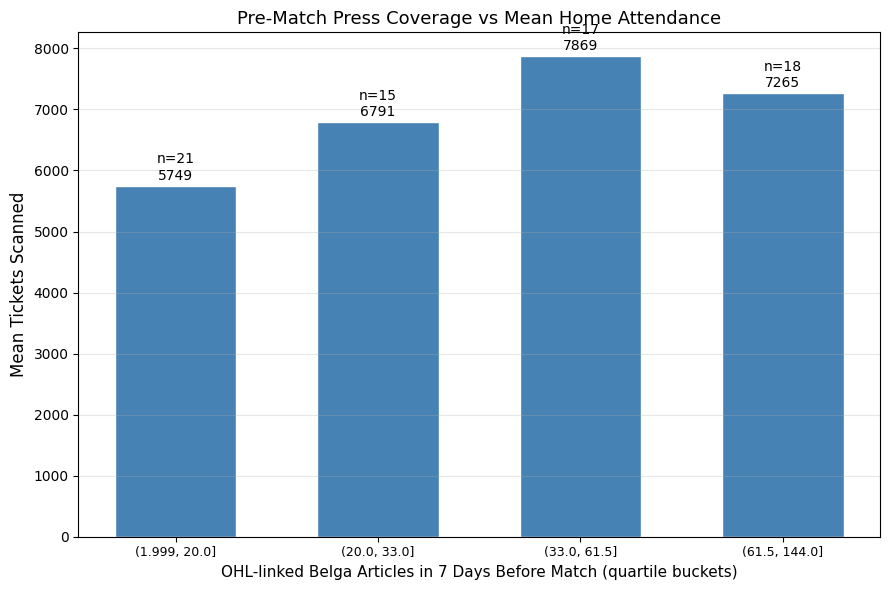

In [30]:
# Use quartile-based buckets so each group is evenly populated
analysis_df['article_bucket'] = pd.qcut(
    analysis_df['press_articles_7d'], q=4, duplicates='drop'
)

bucket_stats = analysis_df.groupby('article_bucket', observed=True)['tickets_scanned'].agg(
    mean_attendance='mean',
    count='count'
).reset_index()

bucket_labels = [str(b) for b in bucket_stats['article_bucket']]

plt.figure(figsize=(9, 6))
bars = plt.bar(
    range(len(bucket_stats)),
    bucket_stats['mean_attendance'],
    color='steelblue', edgecolor='white', width=0.6
)

for bar, (_, row) in zip(bars, bucket_stats.iterrows()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"n={int(row['count'])}\n{int(row['mean_attendance'])}",
        ha='center', va='bottom', fontsize=10
    )

plt.xticks(range(len(bucket_stats)), bucket_labels, fontsize=9)
plt.xlabel('OHL-linked Belga Articles in 7 Days Before Match (quartile buckets)', fontsize=11)
plt.ylabel('Mean Tickets Scanned', fontsize=12)
plt.title('Pre-Match Press Coverage vs Mean Home Attendance', fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Pre-match press coverage shows a generally positive relationship with attendance, with matches receiving more media attention in the week leading up to the game tending to attract higher crowds. Attendance increases notably from low to moderate levels of coverage, indicating that media exposure may help boost fan interest and turnout. However, the slight decline at the highest coverage level suggests the relationship is not strictly linear and that other factors also influence attendance. Overall, press coverage appears to be a meaningful but not sole driver of matchday attendance.
